In [2]:
import os
import sys
import numba
import numpy as np
import pandas as pd

sys.path.append("../..")

from strategy.data.utils import load
from strategy.indicator.common import TR
from strategy.indicator.common import MA
from strategy.indicator.common import ATR
from strategy.common.constant import DAY_MS_COUNT

In [4]:
# df = pd.read_csv('../../data/DOGEUSD_PERP_renko_0.001.csv')
raw = load('DOGEUSD_PERP', '../../data')

In [5]:
period = 8 * 3600000 # 8 hours # DAY_MS_COUNT
k, short, long = 0.618, 20, 150 
df = raw#.iloc[-1440*90:].copy()
df = df.reset_index(drop=True)
df['gid'] = df.start_t // period
gdf = df.groupby('gid').agg({
    'gid': 'first',
    'open':'first', 'high':'max', 'low':'min', 'close':'last'}
)
atr = ATR(short).calc(gdf).to_frame('atr').shift(1)
atr['gid'] = gdf.gid
# atr['ma'] = MA(short).calc(gdf)
# df = df.join(tr, on='gid', rsuffix='_x')
df = df.join(atr, on='gid', rsuffix='_x')
# df['upp'] = round(df.ma + k * df.atr, 5)
# df['dnn'] = round(df.ma - k * df.atr, 5)
# df = df.dropna()
print(df.shape)

(17280, 15)


In [94]:
gdf.reset_index()

,gid,open,high,low,close
0,59429,0.18790,0.19209,0.18140,0.19049
1,59430,0.19049,0.20645,0.18938,0.20019
2,59431,0.20019,0.22545,0.19852,0.21772
3,59432,0.21772,0.22913,0.21602,0.22027
4,59433,0.22028,0.22519,0.20883,0.20989
5,59434,0.20989,0.21866,0.20826,0.20905
6,59435,0.20905,0.21867,0.20890,0.21332
7,59436,0.21332,0.21719,0.20592,0.20657
8,59437,0.20657,0.21132,0.20312,0.20412
9,59438,0.20412,0.20499,0.19602,0.19946


In [107]:
class Indicator:

    def __init__(self, length):
        self.length = length
        self.value = None
        self.hist = []
        self.maxlen = max(2*length, 1000000)

    def update(self, *args, **kw):
        raise NotImplementedError('inplement it yourself!')


class ATR(Indicator):

    def __init__(self, length, df=None):
        super().__init__(length)
        if df is None:
            pass
        else:
            self.init(
                df.high.values,
                df.low.values,
                df.close.values)
    
    def init(self, high, low, close):
        self.value = 0.0
        start_pos = len(close) - self.length
        assert start_pos >= 1, "more hist hloc data needed"
        self.prev_close = close[start_pos - 1]
        for i in range(start_pos, len(close)):
            t1 = abs(high[i] - self.prev_close)
            t2 = abs(low[i] - self.prev_close)
            self.hist.append(max(high[i] - low[i], t1, t2))
            self.value += self.hist[-1]
            self.prev_close = close[i]
        self.value /= self.length
        self.head = self.length - 1
        return self
    
    def calc(self, df):
        lc = df.close.shift(1)
        t1 = df.high - lc
        t2 = df.low - lc
        hl = df.high - df.low
        return pd.concat([
            hl, t1.abs(), t2.abs()],
            axis=1
        ).max(axis=1).rolling(self.length).mean()
    
    def update(self, high, low, close):
        print(self.prev_close, high, low, close)
        t1 = abs(high - self.prev_close)
        t2 = abs(low - self.prev_close)
        v0 = max(high - low, t1, t2)
        
        self.head = (self.head + 1) % self.length
        self.value += (v0 - self.hist[self.head]) / self.length
        # print('before:', self.hist, v0)
        self.hist[self.head] = v0
        # self.value = np.mean(self.hist)
        # print('after:', self.hist, self.value)

        self.prev_close = close
        return self.value

In [ ]:
i = short + 1
A = ATR(short, gdf.head(short + 1))
print(short + 1, A.value)
high, low, close = tuple(gdf.iloc[i].values.tolist()[1:4])
A.update(high, low, close)
print(i, A.value)

21 0.0133525
0.17908 0.1815 0.17033 0.17549
before: [0.017070000000000002, 0.02693000000000001, 0.01311000000000001, 0.016360000000000013, 0.010399999999999993, 0.009770000000000001, 0.011270000000000002, 0.008200000000000013, 0.008970000000000006, 0.008260000000000017, 0.00841, 0.01446, 0.024989999999999984, 0.014229999999999993, 0.008220000000000005, 0.020290000000000002, 0.010509999999999992, 0.008549999999999974, 0.016509999999999997, 0.010540000000000022] 0.011169999999999985
after: [0.011169999999999985, 0.02693000000000001, 0.01311000000000001, 0.016360000000000013, 0.010399999999999993, 0.009770000000000001, 0.011270000000000002, 0.008200000000000013, 0.008970000000000006, 0.008260000000000017, 0.00841, 0.01446, 0.024989999999999984, 0.014229999999999993, 0.008220000000000005, 0.020290000000000002, 0.010509999999999992, 0.008549999999999974, 0.016509999999999997, 0.010540000000000022] 0.0130575
21 0.0130575


: 

In [105]:
t1 = gdf.high - gdf.close.shift(1)
t2 = gdf.low - gdf.close.shift(1)
v0 = gdf.high - gdf.low
pd.concat([t1.abs(), t2.abs(), v0], axis=1).max(axis=1).reset_index(drop=True).T.values

array([0.01069, 0.01707, 0.02693, 0.01311, 0.01636, 0.0104 , 0.00977,
       0.01127, 0.0082 , 0.00897, 0.00826, 0.00841, 0.01446, 0.02499,
       0.01423, 0.00822, 0.02029, 0.01051, 0.00855, 0.01651, 0.01054,
       0.01117, 0.00895, 0.01   , 0.0125 , 0.00952, 0.0093 , 0.00595])

In [82]:
atr.head(short + 2).tail(2).values

array([[1.33525e-02, 5.94490e+04],
       [1.30575e-02, 5.94500e+04]])

In [6]:
# 固定百分比，止盈
@numba.jit(nopython=True)
def break_atr_float(data, length, k1, s1, s2, direct):
    trans, mp = [], 0
    for i in range(length, data.shape[0] - 1):
        t, o, h, l, c, upp, dnn, atr = data[i,0], data[i,1], data[i,2], data[i,3], \
            data[i,4], data[i,5], data[i,6], data[i,7]
        pos = i + 1
        nt, no, nh, nl, nc, nu, nd, natr = data[pos,0], data[pos,1], data[pos,2], data[pos,3], \
            data[pos,4], data[pos,5], data[pos,6], data[i, 7]
        if mp == 0 and upp - no > (k1 * atr):
            price = no
            mp = direct
            entt = nt
            enpp = price
        if mp == 0 and no - dnn > (k1 * atr):
            price = no
            mp = -direct
            entt = nt
            enpp = price
        if mp != 0:
            # long 
            spp = round(enpp - s1 * atr, 5)
            if mp > 0 and nl <= spp: # 止损
                price = min(no, spp)
                trans.append([mp, enpp, price, entt, nt])
                mp = 0
            spp = round(enpp + s2 * atr, 5)
            if mp > 0 and nh >= spp: # 止盈
                price = spp
                trans.append([mp, enpp, price, entt, nt])
                mp = 0
            spp = round(enpp + s1 * atr, 5)
            # short
            if mp < 0 and nh >= spp: # 止损
                price = max(no, spp)
                trans.append([mp, enpp, price, entt, nt])
                mp = 0
            spp = round(enpp - s2 * atr, 5)
            if mp < 0 and nl <= spp: # 止盈
                price = spp
                trans.append([mp, enpp, price, entt, nt])
                mp = 0
    return trans

In [19]:
from strategy.strategy.store import break_fix, break_float, break_atr

def trans2pnl(trans, param, fee):
    rcd = pd.DataFrame(trans, columns=['pos', 'open', 'close', 'entt', 'close_t'])
    profit = rcd.pos * (rcd.close - rcd.open)
    commis = rcd.pos.abs() * (rcd.close + rcd.open) * fee
    res = (profit - commis) / rcd.open
    pnl = res.sum()
    s = 1 + res.cumsum()
    mdd = (s.expanding(min_periods=1).max() - s) / s
    mdd = mdd.max()
    if param:
        res.cumsum().plot(title=f"param:{param}, pnl={pnl:.4f})")
        res.index = rcd.entt
        return res, rcd
    return pnl, mdd

In [18]:
direct = 1
best = [0]
for length in range(20, 150, 20):
    for k1 in np.arange(0.3, 3.1, 0.3):
        for s1 in np.arange(0.3, 3.1, 0.3):
            for s2 in np.arange(0.3, 3.1, 0.3):
                param = [0, 0, length, k1, s1, s2, direct]
                dp = df
                dp['upp'] = dp.high.rolling(length).max()
                dp['dnn'] = dp.low.rolling(length).min()
                trans = break_atr(dp[[
                        "start_t", "open", "high",
                        "low", "close", "upp", "dnn", "atr"]].values, *param[2:])
                param[0], param[1] = trans2pnl(trans, None)
                if param[0] > best[0]:
                    best = param
                    print("best:", best)
                # print('debug', param)

best: [0.0758979943855648, 0.06857020183145339, 20, 0.3, 0.3, 0.3, 1]
best: [0.07625098449891657, 0.18120477262883056, 20, 0.3, 0.6, 0.8999999999999999, 1]
best: [0.11809431386431718, 0.03984191751607984, 20, 0.3, 0.6, 2.6999999999999997, 1]
best: [0.14061273031767005, 0.03586694801940584, 20, 0.3, 0.6, 2.9999999999999996, 1]
best: [0.1815230278262466, 0.0, 20, 0.3, 0.8999999999999999, 2.9999999999999996, 1]
best: [0.18290795317849534, 0.0, 40, 0.3, 0.8999999999999999, 2.9999999999999996, 1]
best: [0.1848512483635683, 0.0, 60, 0.3, 1.2, 2.9999999999999996, 1]
best: [0.18600538671433942, 0.0, 80, 0.3, 1.2, 2.9999999999999996, 1]
best: [0.1862350767643926, 0.10924117606013638, 80, 0.6, 0.3, 1.2, 1]
best: [0.19094145564567394, 0.12290013557589675, 80, 0.6, 0.6, 1.2, 1]
best: [0.19171209551838678, 0.12198902003256613, 80, 0.6, 1.8, 1.2, 1]
best: [0.23496000390574007, 0.12388296772821106, 120, 0.3, 1.8, 0.3, 1]


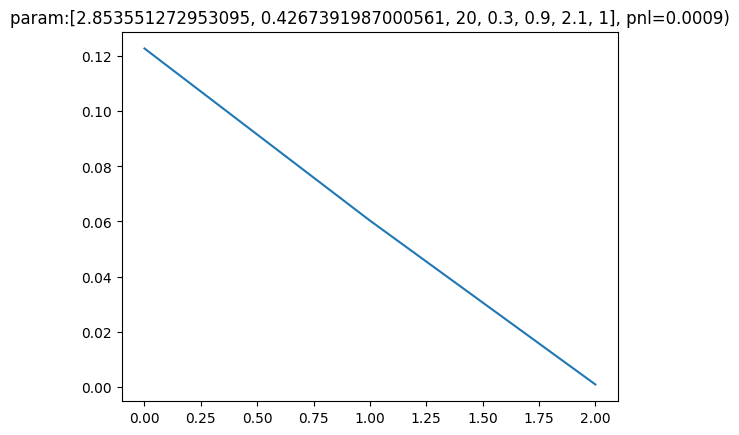

In [29]:
# best: [0.0758979943855648, 0.06857020183145339, 20, 0.3, 0.3, 0.3, 1]
# best: [0.07625098449891657, 0.18120477262883056, 20, 0.3, 0.6, 0.8999999999999999, 1]
# best: [0.11809431386431718, 0.03984191751607984, 20, 0.3, 0.6, 2.6999999999999997, 1]
# best: [0.14061273031767005, 0.03586694801940584, 20, 0.3, 0.6, 2.9999999999999996, 1]
# best: [0.1815230278262466, 0.0, 20, 0.3, 0.8999999999999999, 2.9999999999999996, 1]
# best: [0.18290795317849534, 0.0, 40, 0.3, 0.8999999999999999, 2.9999999999999996, 1]
# best: [0.1848512483635683, 0.0, 60, 0.3, 1.2, 2.9999999999999996, 1]
# best: [0.18600538671433942, 0.0, 80, 0.3, 1.2, 2.9999999999999996, 1]
# best: [0.1862350767643926, 0.10924117606013638, 80, 0.6, 0.3, 1.2, 1]
# best: [0.19094145564567394, 0.12290013557589675, 80, 0.6, 0.6, 1.2, 1]
# best: [0.19171209551838678, 0.12198902003256613, 80, 0.6, 1.8, 1.2, 1]
# best: [0.23496000390574007, 0.12388296772821106, 120, 0.3, 1.8, 0.3, 1]
for best in [[2.853551272953095, 0.4267391987000561, 20, 0.3, 0.9, 2.1, 1]]:
        # df['atr'] = df.tr.shift(-1).rolling(20).mean()
        df['upp'] = df.high.rolling(best[2]).max()
        df['dnn'] = df.low.rolling(best[2]).min()
        trans = break_atr(df[[
                "start_t", "open", "high",
                "low", "close", "upp", "dnn", "atr"]].values, *best[2:])
        # res_atr, rcd_atr = trans2pnl(trans)
        res, rcd = trans2pnl(trans, best, 0.0005)

In [30]:
df['']

,start_t,open,high,low,close,volume,end_t,amount,trade_cnt,taker_vol,taker_amt,reserved,gid,atr,gid_x,upp,dnn
0,1711324800000,0.17669,0.17735,0.17667,0.17725,45354,1711324859999,2.562847e+06,528,28969,1.637416e+06,0,59421,NaN,59421,NaN,NaN
1,1711324860000,0.17727,0.17766,0.17720,0.17720,25206,1711324919999,1.420604e+06,443,11233,6.331054e+05,0,59421,NaN,59421,NaN,NaN
2,1711324920000,0.17720,0.17721,0.17672,0.17699,18971,1711324979999,1.071737e+06,310,7236,4.090317e+05,0,59421,NaN,59421,NaN,NaN
3,1711324980000,0.17700,0.17719,0.17628,0.17651,24835,1711325039999,1.405585e+06,446,8862,5.019142e+05,0,59421,NaN,59421,NaN,NaN
4,1711325040000,0.17651,0.17720,0.17650,0.17689,28205,1711325099999,1.594195e+06,460,10956,6.195318e+05,0,59421,NaN,59421,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17275,1712361300000,0.17783,0.17783,0.17757,0.17757,10123,1712361359999,5.695913e+05,167,2685,1.510726e+05,0,59456,0.011812,59456,0.1783,0.17746
17276,1712361360000,0.17756,0.17768,0.17755,0.17763,5034,1712361419999,2.834573e+05,69,4500,2.534025e+05,0,59456,0.011812,59456,0.1783,0.17746
17277,1712361420000,0.17762,0.17762,0.17699,0.17712,81687,1712361479999,4.609155e+06,520,6909,3.897615e+05,0,59456,0.011812,59456,0.1783,0.17699
17278,1712361480000,0.17712,0.17739,0.17712,0.17738,13301,1712361539999,7.502615e+05,198,7791,4.395571e+05,0,59456,0.011812,59456,0.1783,0.17699


In [43]:
import io

content = ''
with open("../../backtest.log") as fp:
    for line in fp:
        if 'KLINE' in line:
            content += line.split('|')[1]
xdf = pd.read_csv(io.StringIO(content), header=None)
xdf = xdf.map(lambda x: x.split('=')[1]).astype(float)
xdf.columns = ['mp', 'start_t', 'o', 'h', 'l', 'c', 'upp', 'dnn', 'atr']
xdf.start_t = xdf.start_t.astype(int)
xdf

,mp,start_t,o,h,l,c,upp,dnn,atr
0,0.0,1711556940000,0.18790,0.18849,0.18787,0.18792,0.19023,0.18679,0.010735
1,0.0,1711557000000,0.18792,0.18871,0.18783,0.18840,0.19023,0.18679,0.010735
2,0.0,1711557060000,0.18840,0.18946,0.18835,0.18901,0.19023,0.18679,0.010735
3,0.0,1711557120000,0.18901,0.18930,0.18826,0.18829,0.19023,0.18679,0.010735
4,0.0,1711557180000,0.18829,0.18856,0.18818,0.18839,0.19023,0.18679,0.010735
...,...,...,...,...,...,...,...,...,...
13405,1.0,1712361240000,0.17804,0.17804,0.17782,0.17782,0.17831,0.17746,0.010854
13406,1.0,1712361300000,0.17782,0.17783,0.17757,0.17757,0.17831,0.17746,0.010854
13407,1.0,1712361360000,0.17757,0.17769,0.17755,0.17763,0.17831,0.17746,0.010854
13408,1.0,1712361420000,0.17763,0.17763,0.17710,0.17712,0.17831,0.17710,0.010854


In [66]:
x = df[['start_t', 'open', 'high', 'low', 'close', 'upp', 'dnn', 'atr']].set_index('start_t')
y = x.join(xdf.set_index('start_t'), rsuffix='_x', how='inner')

In [68]:
(y['atr'] - y['atr_x'])/0.18

start_t
1711556940000         NaN
1711557000000         NaN
1711557060000         NaN
1711557120000         NaN
1711557180000         NaN
                   ...   
1712361240000    0.005325
1712361300000    0.005325
1712361360000    0.005325
1712361420000    0.005325
1712361480000    0.005325
Length: 13410, dtype: float64

In [64]:
xdf['gid'] = xdf.start_t // (8 * 3600000)
gdf = xdf.groupby('gid').agg(
    {'o': 'first', 'h': 'max', 'l':'min', 'c':'last'})
gdf.columns = ['open', 'high', 'low', 'close']
atr = ATR(20).calc(gdf).to_frame('atr2')
atr['gid'] = gdf.index
xdf = xdf.join(atr, on='gid', rsuffix='_y')
xdf

,mp,start_t,o,h,l,c,upp,dnn,atr,gid,atr2,gid_y
0,0.0,1711556940000,0.18790,0.18849,0.18787,0.18792,0.19023,0.18679,0.010735,59429,NaN,59429
1,0.0,1711557000000,0.18792,0.18871,0.18783,0.18840,0.19023,0.18679,0.010735,59429,NaN,59429
2,0.0,1711557060000,0.18840,0.18946,0.18835,0.18901,0.19023,0.18679,0.010735,59429,NaN,59429
3,0.0,1711557120000,0.18901,0.18930,0.18826,0.18829,0.19023,0.18679,0.010735,59429,NaN,59429
4,0.0,1711557180000,0.18829,0.18856,0.18818,0.18839,0.19023,0.18679,0.010735,59429,NaN,59429
...,...,...,...,...,...,...,...,...,...,...,...,...
13405,1.0,1712361240000,0.17804,0.17804,0.17782,0.17782,0.17831,0.17746,0.010854,59456,0.011476,59456
13406,1.0,1712361300000,0.17782,0.17783,0.17757,0.17757,0.17831,0.17746,0.010854,59456,0.011476,59456
13407,1.0,1712361360000,0.17757,0.17769,0.17755,0.17763,0.17831,0.17746,0.010854,59456,0.011476,59456
13408,1.0,1712361420000,0.17763,0.17763,0.17710,0.17712,0.17831,0.17710,0.010854,59456,0.011476,59456


In [61]:
xdf.tail()

,mp,start_t,o,h,l,c,upp,dnn,atr,gid
13405,1.0,1712361240000,0.17804,0.17804,0.17782,0.17782,0.17831,0.17746,0.010854,59456
13406,1.0,1712361300000,0.17782,0.17783,0.17757,0.17757,0.17831,0.17746,0.010854,59456
13407,1.0,1712361360000,0.17757,0.17769,0.17755,0.17763,0.17831,0.17746,0.010854,59456
13408,1.0,1712361420000,0.17763,0.17763,0.17710,0.17712,0.17831,0.17710,0.010854,59456
13409,1.0,1712361480000,0.17712,0.17738,0.17712,0.17736,0.17831,0.17710,0.010854,59456


In [62]:
x.tail()

,open,high,low,close,upp,dnn,atr
start_t,,,,,,,
1712361300000,0.17783,0.17783,0.17757,0.17757,0.1783,0.17746,0.011812
1712361360000,0.17756,0.17768,0.17755,0.17763,0.1783,0.17746,0.011812
1712361420000,0.17762,0.17762,0.17699,0.17712,0.1783,0.17699,0.011812
1712361480000,0.17712,0.17739,0.17712,0.17738,0.1783,0.17699,0.011812
1712361540000,0.17740,0.17741,0.17729,0.17735,0.1783,0.17699,0.011812


In [52]:
set(x.start_t) - set(xdf.start_t)

{1711349760000,
 1711411200000,
 1711534080000,
 1711472640000,
 1711518720000,
 1711457280000,
 1711334400000,
 1711395840000,
 1711380480000,
 1711441920000,
 1711470240000,
 1711349460000,
 1711345860000,
 1711466640000,
 1711343460000,
 1711464240000,
 1711362900000,
 1711424340000,
 1711485780000,
 1711547220000,
 1711347540000,
 1711408980000,
 1711531860000,
 1711470420000,
 1711332180000,
 1711393620000,
 1711337460000,
 1711460640000,
 1711458240000,
 1711457040000,
 1711333860000,
 1711454640000,
 1711376040000,
 1711437480000,
 1711498920000,
 1711422120000,
 1711545000000,
 1711360680000,
 1711483560000,
 1711345320000,
 1711406760000,
 1711468200000,
 1711451040000,
 1711330260000,
 1711448640000,
 1711447440000,
 1711445040000,
 1711327740000,
 1711389180000,
 1711450620000,
 1711512060000,
 1711373820000,
 1711496700000,
 1711435260000,
 1711358460000,
 1711419900000,
 1711481340000,
 1711441440000,
 1711439040000,
 1711437840000,
 1711435440000,
 1711340880000,
 1711463

In [25]:
rcd.entt = pd.to_datetime(rcd.entt * 1e6)
rcd.close_t = pd.to_datetime(rcd.close_t * 1e6)
rcd

,pos,open,close,entt,close_t
0,-1.0,0.21778,0.19084,2024-03-31 18:36:00,2024-04-02 02:37:00
1,1.0,0.19309,0.18122,2024-04-02 02:38:00,2024-04-02 09:03:00
2,1.0,0.18207,0.17142,2024-04-02 09:04:00,2024-04-05 09:19:00


In [28]:
pd.to_datetime(df.dropna().start_t*1e6)

9600    2024-03-31 16:00:00
9601    2024-03-31 16:01:00
9602    2024-03-31 16:02:00
9603    2024-03-31 16:03:00
9604    2024-03-31 16:04:00
                ...        
17275   2024-04-05 23:55:00
17276   2024-04-05 23:56:00
17277   2024-04-05 23:57:00
17278   2024-04-05 23:58:00
17279   2024-04-05 23:59:00
Name: start_t, Length: 7680, dtype: datetime64[ns]

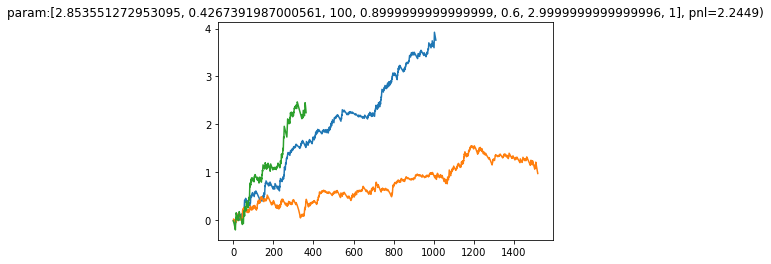

: 

In [ ]:
for best in [[4.253175684881241, 0, 100, 0.6, 0.3, 2.0999999999999996, 1],
        [2.8446943762365895, 0.19912999053497468, 80, 0.3, 0.3, 1.5, 1],
        [2.853551272953095, 0.4267391987000561, 100, 0.8999999999999999, 0.6, 2.9999999999999996, 1]]:
        # df['atr'] = df.tr.shift(-1).rolling(20).mean()
        df['upp'] = df.high.rolling(best[2]).max()
        df['dnn'] = df.low.rolling(best[2]).min()
        trans = break_atr_float(df[[
                "start_t", "open", "high",
                "low", "close", "upp", "dnn", "atr"]].values, *best[2:])
        res_atr, rcd_atr = trans2pnl(trans, best)

In [ ]:
direct = -1
best = [0]
for length in range(20, 150, 20):
    for k1 in np.arange(0.3, 3.1, 0.3):
        for s1 in np.arange(0.3, 3.1, 0.3):
            for s2 in np.arange(0.3, 3.1, 0.3):
                param = [0, 0, length, k1, s1, s2, direct]
                dp = df
                dp['upp'] = dp.high.rolling(length).max()
                dp['dnn'] = dp.low.rolling(length).min()
                trans = break_atr(dp[[
                        "start_t", "open", "high",
                        "low", "close", "upp", "dnn", "atr"]].values, *param[2:])
                param[0], param[1] = trans2pnl(trans, None)
                if param[0] > best[0]:
                    best = param
                    print("best:", best)
                # print('debug', param)

best: [0.6212140541638309, 0.8427935173844573, 20, 0.3, 2.9999999999999996, 2.0999999999999996, -1]
best: [0.6698900757447417, 0.5925326647908616, 60, 1.5, 2.9999999999999996, 2.6999999999999997, -1]
best: [0.8267952168981532, 0.6792726560952745, 100, 0.6, 2.6999999999999997, 2.6999999999999997, -1]


: 

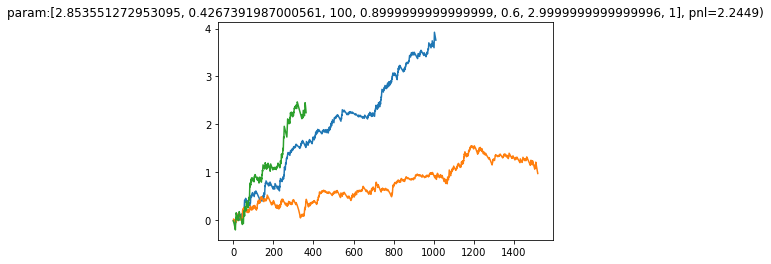

: 

In [ ]:
for best in [[4.253175684881241, 0, 100, 0.6, 0.3, 2.0999999999999996, 1],
        [2.8446943762365895, 0.19912999053497468, 80, 0.3, 0.3, 1.5, 1],
        [2.853551272953095, 0.4267391987000561, 100, 0.8999999999999999, 0.6, 2.9999999999999996, 1]]:
        # df['atr'] = df.tr.shift(-1).rolling(20).mean()
        df['upp'] = df.high.rolling(best[2]).max()
        df['dnn'] = df.low.rolling(best[2]).min()
        trans = break_atr(df[[
                "start_t", "open", "high",
                "low", "close", "upp", "dnn", "atr"]].values, *best[2:])
        res_atr, rcd_atr = trans2pnl(trans, best)

ValueError: too many values to unpack (expected 2)

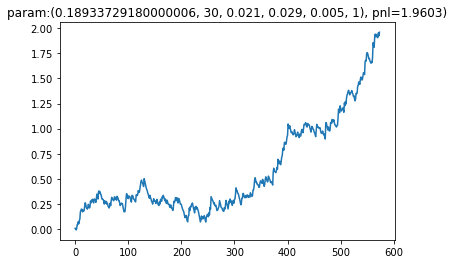

: 

In [ ]:
# ======================================================================================
# 止盈
best = (0.11454144600000016, 10, 0.029, 0.005, 0.005, -1) # -1：非常适合震荡
best = (0.18933729180000006, 30, 0.021, 0.029, 0.005, 1) # 1：非常适合趋势 
pnl, length, k1, s1, s2, direct = best

df = raw.reset_index(drop=True)
df['upp'] = df.high.rolling(length).max()
df['dnn'] = df.low.rolling(length).min()

trans = break_float(df[[
        "start_t", "open", "high",
        "low", "close", "upp", "dnn"]].values, length, k1, s1, s2, direct)

res_float, rcd_float = trans2pnl(trans, best)
# 

In [ ]:
res = res_fix.to_frame('fix').join(res_float.to_frame('float'), how='outer').fillna(0)
res

,fix,float
entt,,
1.672644e+12,-0.023364,0.007236
1.672644e+12,0.022545,0.000000
1.672645e+12,-0.023413,0.000000
1.673261e+12,0.000000,-0.007305
1.673264e+12,0.022623,0.000000
...,...,...
1.709584e+12,-0.023407,0.000000
1.709584e+12,0.022582,0.000000
1.709585e+12,0.000000,-0.028915


: 

fix, count:753, mdd:18.69%, win:loss:0.97 pnl:2.252610, win:57.37%
float, count:574, mdd:40.35%, win:loss:1.88 pnl:1.960329, win:41.81%
fac:0.000, count:1032, mdd:40.35%, win:loss:1.88 pnl:1.960329, win:23.26%
fac:0.010, count:1032, mdd:39.84%, win:loss:1.47 pnl:1.963252, win:47.87%
fac:0.020, count:1032, mdd:39.44%, win:loss:1.47 pnl:1.966174, win:47.97%
fac:0.030, count:1032, mdd:39.04%, win:loss:1.46 pnl:1.969097, win:48.06%
fac:0.040, count:1032, mdd:38.64%, win:loss:1.44 pnl:1.972020, win:48.35%
fac:0.050, count:1032, mdd:38.25%, win:loss:1.43 pnl:1.974943, win:48.55%
fac:0.060, count:1032, mdd:37.86%, win:loss:1.42 pnl:1.977866, win:48.84%
fac:0.070, count:1032, mdd:37.48%, win:loss:1.40 pnl:1.980789, win:49.13%
fac:0.080, count:1032, mdd:37.10%, win:loss:1.39 pnl:1.983711, win:49.22%
fac:0.090, count:1032, mdd:36.72%, win:loss:1.39 pnl:1.986634, win:49.22%
fac:0.100, count:1032, mdd:36.35%, win:loss:1.39 pnl:1.989557, win:49.22%
fac:0.110, count:1032, mdd:35.98%, win:loss:1.38 p

<AxesSubplot:xlabel='entt'>

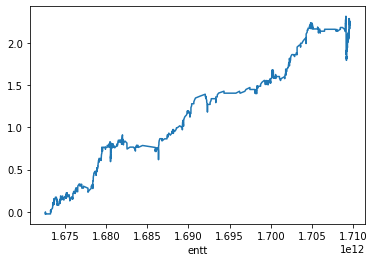

: 

In [ ]:
def analysis(prefix, t):
    w = (t > 0).sum() / t.shape[0]
    r = t[t > 0].mean() / abs(t[t < 0].mean())
    s = 1 + t.cumsum()
    mdd = (s.expanding(min_periods=1).max() - s) / s
    mdd = mdd.max()
    print(
        f"{prefix}, count:{t.shape[0]}, mdd:{mdd * 100:.2f}%, win:loss:{r:.2f} "
        f"pnl:{t.sum():.6f}, win:{w * 100:.2f}%")
    return mdd


analysis('fix', res_fix)
analysis('float', res_float)
mdd, fin_fac = 1, 0
for fac in np.arange(0, 1.001, 0.01):
    t = fac * res.fix + (1 - fac) * res.float
    mdd_t = analysis(f'fac:{fac:.3f}', t)
    if mdd_t < mdd:
        fin_fac = fac
        mdd = mdd_t
t = fac * res.fix + (1 - fac) * res.float
print(fin_fac, mdd)
t.cumsum().plot()

In [ ]:
s = res_fix.cumsum()
s.expanding(min_periods=1).max() - s

entt
1.672644e+12    0.000000
1.672644e+12    0.000000
1.672645e+12    0.023413
1.673264e+12    0.000790
1.673272e+12    0.000000
                  ...   
1.709577e+12    0.059783
1.709578e+12    0.083214
1.709584e+12    0.106620
1.709584e+12    0.084038
1.709585e+12    0.061424
Length: 753, dtype: float64

: 

0.5219580053289277


<AxesSubplot:xlabel='entt'>

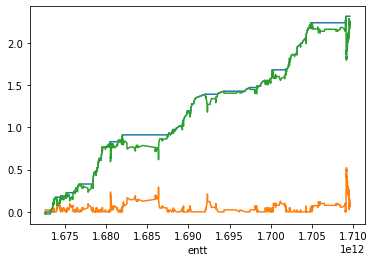

: 

In [ ]:
s = res.fix.cumsum() # ((res.float + res.fix)/2).cumsum()
d = s.expanding(min_periods=1).max()
d.plot()
(d - s).plot()
print((d - s).max())
s.plot()

<AxesSubplot:xlabel='entt'>

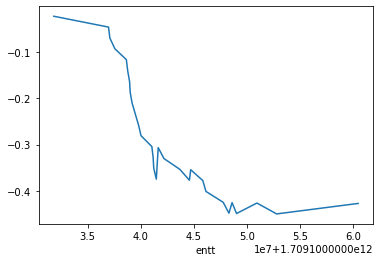

: 

In [ ]:
res_fix[res_fix.index[599]: res_fix.index[630]].cumsum().plot()

In [ ]:
x = rcd_fix.iloc[599:630].copy()
x.entt = pd.to_datetime(x.entt * 1e6)
x.close_t = pd.to_datetime(x.close_t * 1e6)
x['gross'] = x.close - x.open
x

,pos,open,close,entt,close_t,gross
599,-1.0,0.09995,0.10225,2024-02-28 14:50:00,2024-02-28 16:15:00,0.00230
600,-1.0,0.10229,0.10464,2024-02-28 16:16:00,2024-02-28 16:17:00,0.00235
601,-1.0,0.10469,0.10710,2024-02-28 16:18:00,2024-02-28 16:25:00,0.00241
602,-1.0,0.10581,0.10824,2024-02-28 16:26:00,2024-02-28 16:43:00,0.00243
603,-1.0,0.10823,0.11072,2024-02-28 16:44:00,2024-02-28 16:45:00,0.00249
604,-1.0,0.11155,0.11412,2024-02-28 16:46:00,2024-02-28 16:48:00,0.00257
605,-1.0,0.11461,0.11725,2024-02-28 16:49:00,2024-02-28 16:49:00,0.00264
606,-1.0,0.11538,0.11803,2024-02-28 16:50:00,2024-02-28 16:52:00,0.00265
607,-1.0,0.11668,0.11936,2024-02-28 16:53:00,2024-02-28 16:57:00,0.00268
608,-1.0,0.11955,0.12230,2024-02-28 16:58:00,2024-02-28 17:02:00,0.00275


: 

/Users/paul/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 20215 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/paul/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 26684 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/paul/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 26085 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/paul/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 26399 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/paul/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backends/backend_agg.py:240: RuntimeWarning: Glyph 32447 missing from current font.
  font.set_text(s, 0.0, flags=flags)
/Users/paul/opt/anaconda3/lib/python3.9/site-packages/matplotlib/backe

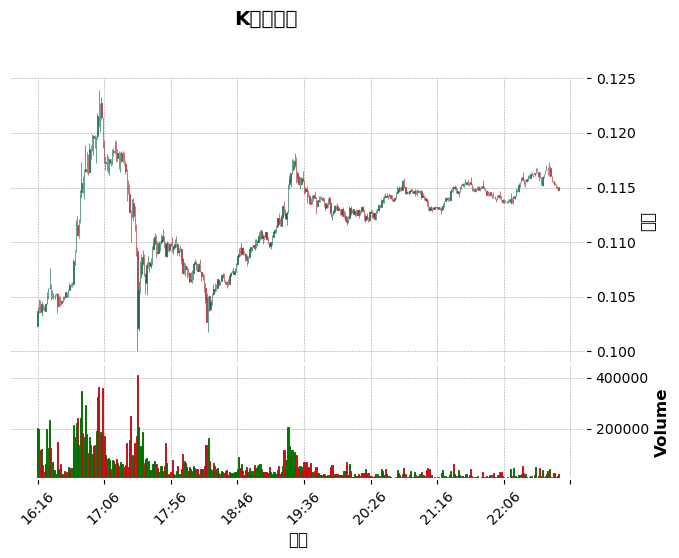

: 

In [ ]:
import mplfinance as mpf
import pandas as pd

# 假设您有一个DataFrame 'df'，其中包含OHLC（开盘价、最高价、最低价、收盘价）数据
# 数据应该有一个DatetimeIndex，且列名分别为'Open', 'High', 'Low', 'Close'

# 创建一个包含K线图的DataFrame
df = raw[(raw.start_t >= res_fix.index[600]) & (raw.end_t <= res_fix.index[630])]
df.index = pd.to_datetime(df.start_t*1e6)

# 将DataFrame的索引设置为日期
# df.index = pd.date_range('20210101', periods=5)

# 绘制K线图
mpf.plot(df, type='candle', style='charles',
         title='K线图示例',
         ylabel='价格',
         xlabel='日期',
         volume=True)  # 显示成交量

: 